In [182]:
!pip install numpy pandas matplotlib seaborn scipy pearsonr

In [183]:
import numpy as num
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [184]:
df_energy=pd.read_csv('9_energy_consumption.csv')
display(df_energy)

,household_id,household_size,num_adults,num_children,home_ownership,house_type,income_bracket,square_footage,num_bedrooms,num_bathrooms,...,has_led_lighting,has_energy_star_appliances,has_solar_panels,energy_audit_done,avg_daily_hours_home,works_from_home,electric_vehicle_count,peak_usage_time,monthly_kwh_consumption,high_consumption
0,HH_00000001,5,5,0,Rent,Single Family,$40k-$75k,2755.0,5,3.5,...,Yes,Yes,No,Yes,18.0,No,0,Evening,3859.0,Yes
1,HH_00000002,4,3,1,Own,Single Family,$75k-$120k,2787.0,5,4.5,...,Yes,Yes,No,Yes,10.0,No,1,Evening,4213.0,Yes
2,HH_00000003,2,2,0,Rent,Single Family,<$40k,1099.0,2,2.4,...,No,Yes,No,No,15.0,No,0,Morning,2822.0,No
3,HH_00000004,1,1,0,Own,Single Family,$120k+,1298.0,1,1.0,...,Yes,Yes,No,No,6.0,No,1,Afternoon,2077.0,No
4,HH_00000005,2,1,1,Rent,Apartment,$75k-$120k,1109.0,3,3.1,...,Yes,Yes,No,Yes,13.0,No,0,Morning,1888.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,HH_00014996,4,4,0,Own,Condo,$75k-$120k,2018.0,3,3.1,...,Yes,No,No,No,21.0,No,1,Afternoon,3829.0,Yes
14996,HH_00014997,5,5,0,Own,Single Family,<$40k,3200.0,5,3.5,...,Yes,Yes,Yes,Yes,10.0,Yes,0,Morning,3778.0,Yes
14997,HH_00014998,3,2,1,Own,Condo,$40k-$75k,2003.0,3,3.1,...,Yes,Yes,No,No,12.0,Yes,0,Evening,3016.0,Yes
14998,HH_00014999,2,2,0,Own,Single Family,$40k-$75k,1230.0,1,1.7,...,No,Yes,No,No,NaN,Yes,0,Evening,2465.0,No


In [185]:
# df_energy[['house_type','monthly_kwh_consumption']].corr()

In [186]:
df_energy.columns

Index(['household_id', 'household_size', 'num_adults', 'num_children',
       'home_ownership', 'house_type', 'income_bracket', 'square_footage',
       'num_bedrooms', 'num_bathrooms', 'house_age_years',
       'insulation_quality', 'num_floors', 'has_basement', 'heating_type',
       'cooling_type', 'thermostat_setting_winter',
       'thermostat_setting_summer', 'climate_zone', 'num_refrigerators',
       'has_dishwasher', 'has_washer_dryer', 'has_electric_water_heater',
       'has_pool', 'has_spa_hot_tub', 'num_tvs', 'num_computers',
       'has_smart_thermostat', 'has_led_lighting',
       'has_energy_star_appliances', 'has_solar_panels', 'energy_audit_done',
       'avg_daily_hours_home', 'works_from_home', 'electric_vehicle_count',
       'peak_usage_time', 'monthly_kwh_consumption', 'high_consumption'],
      dtype='str')

In [187]:
df_energy.info()
df_energy.describe()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 38 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   household_id                15000 non-null  str    
 1   household_size              15000 non-null  int64  
 2   num_adults                  15000 non-null  int64  
 3   num_children                15000 non-null  int64  
 4   home_ownership              15000 non-null  str    
 5   house_type                  15000 non-null  str    
 6   income_bracket              15000 non-null  str    
 7   square_footage              14400 non-null  float64
 8   num_bedrooms                15000 non-null  int64  
 9   num_bathrooms               15000 non-null  float64
 10  house_age_years             15000 non-null  int64  
 11  insulation_quality          15000 non-null  str    
 12  num_floors                  15000 non-null  int64  
 13  has_basement                15000 non-null

,household_size,num_adults,num_children,square_footage,num_bedrooms,num_bathrooms,house_age_years,num_floors,thermostat_setting_winter,thermostat_setting_summer,num_refrigerators,num_tvs,num_computers,avg_daily_hours_home,electric_vehicle_count,monthly_kwh_consumption
count,15000.000000,15000.000000,15000.000000,14400.000000,15000.000000,15000.000000,15000.000000,15000.000000,14400.000000,15000.000000,15000.00000,15000.000000,15000.000000,14400.000000,15000.000000,15000.000000
mean,2.830933,2.552867,0.278067,1929.739792,2.872733,2.540373,24.224200,1.750200,69.511528,73.544867,1.27500,3.057133,2.498400,13.512986,0.405867,3054.684867
std,1.299357,1.315898,0.503020,596.496344,1.415675,1.053698,23.190453,0.621792,2.981179,2.948045,0.50852,1.661220,1.590356,3.976698,0.636003,749.143293
min,1.000000,1.000000,0.000000,222.000000,1.000000,1.000000,1.000000,1.000000,60.000000,68.000000,1.00000,1.000000,0.000000,4.000000,0.000000,932.000000
25%,2.000000,1.000000,0.000000,1500.000000,2.000000,1.700000,7.000000,1.000000,67.000000,71.000000,1.00000,2.000000,1.000000,11.000000,0.000000,2510.000000
50%,3.000000,2.000000,0.000000,1879.000000,3.000000,2.400000,17.000000,2.000000,70.000000,74.000000,1.00000,3.000000,2.000000,13.000000,0.000000,3010.000000
75%,4.000000,3.000000,1.000000,2324.000000,4.000000,3.100000,35.000000,2.000000,72.000000,76.000000,1.00000,4.000000,3.000000,16.000000,1.000000,3555.000000
max,6.000000,6.000000,2.000000,4102.000000,6.000000,5.000000,100.000000,3.000000,80.000000,82.000000,3.00000,10.000000,8.000000,24.000000,3.000000,5000.000000


In [188]:
display(df_energy.shape)


(15000, 38)

In [189]:
display(df_energy.info())

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 38 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   household_id                15000 non-null  str    
 1   household_size              15000 non-null  int64  
 2   num_adults                  15000 non-null  int64  
 3   num_children                15000 non-null  int64  
 4   home_ownership              15000 non-null  str    
 5   house_type                  15000 non-null  str    
 6   income_bracket              15000 non-null  str    
 7   square_footage              14400 non-null  float64
 8   num_bedrooms                15000 non-null  int64  
 9   num_bathrooms               15000 non-null  float64
 10  house_age_years             15000 non-null  int64  
 11  insulation_quality          15000 non-null  str    
 12  num_floors                  15000 non-null  int64  
 13  has_basement                15000 non-null

None

In [190]:
display(df_energy.describe())

,household_size,num_adults,num_children,square_footage,num_bedrooms,num_bathrooms,house_age_years,num_floors,thermostat_setting_winter,thermostat_setting_summer,num_refrigerators,num_tvs,num_computers,avg_daily_hours_home,electric_vehicle_count,monthly_kwh_consumption
count,15000.000000,15000.000000,15000.000000,14400.000000,15000.000000,15000.000000,15000.000000,15000.000000,14400.000000,15000.000000,15000.00000,15000.000000,15000.000000,14400.000000,15000.000000,15000.000000
mean,2.830933,2.552867,0.278067,1929.739792,2.872733,2.540373,24.224200,1.750200,69.511528,73.544867,1.27500,3.057133,2.498400,13.512986,0.405867,3054.684867
std,1.299357,1.315898,0.503020,596.496344,1.415675,1.053698,23.190453,0.621792,2.981179,2.948045,0.50852,1.661220,1.590356,3.976698,0.636003,749.143293
min,1.000000,1.000000,0.000000,222.000000,1.000000,1.000000,1.000000,1.000000,60.000000,68.000000,1.00000,1.000000,0.000000,4.000000,0.000000,932.000000
25%,2.000000,1.000000,0.000000,1500.000000,2.000000,1.700000,7.000000,1.000000,67.000000,71.000000,1.00000,2.000000,1.000000,11.000000,0.000000,2510.000000
50%,3.000000,2.000000,0.000000,1879.000000,3.000000,2.400000,17.000000,2.000000,70.000000,74.000000,1.00000,3.000000,2.000000,13.000000,0.000000,3010.000000
75%,4.000000,3.000000,1.000000,2324.000000,4.000000,3.100000,35.000000,2.000000,72.000000,76.000000,1.00000,4.000000,3.000000,16.000000,1.000000,3555.000000
max,6.000000,6.000000,2.000000,4102.000000,6.000000,5.000000,100.000000,3.000000,80.000000,82.000000,3.00000,10.000000,8.000000,24.000000,3.000000,5000.000000


In [191]:
display(df_energy.head())

,household_id,household_size,num_adults,num_children,home_ownership,house_type,income_bracket,square_footage,num_bedrooms,num_bathrooms,...,has_led_lighting,has_energy_star_appliances,has_solar_panels,energy_audit_done,avg_daily_hours_home,works_from_home,electric_vehicle_count,peak_usage_time,monthly_kwh_consumption,high_consumption
0,HH_00000001,5,5,0,Rent,Single Family,$40k-$75k,2755.0,5,3.5,...,Yes,Yes,No,Yes,18.0,No,0,Evening,3859.0,Yes
1,HH_00000002,4,3,1,Own,Single Family,$75k-$120k,2787.0,5,4.5,...,Yes,Yes,No,Yes,10.0,No,1,Evening,4213.0,Yes
2,HH_00000003,2,2,0,Rent,Single Family,<$40k,1099.0,2,2.4,...,No,Yes,No,No,15.0,No,0,Morning,2822.0,No
3,HH_00000004,1,1,0,Own,Single Family,$120k+,1298.0,1,1.0,...,Yes,Yes,No,No,6.0,No,1,Afternoon,2077.0,No
4,HH_00000005,2,1,1,Rent,Apartment,$75k-$120k,1109.0,3,3.1,...,Yes,Yes,No,Yes,13.0,No,0,Morning,1888.0,No


In [192]:
display(df_energy.nunique())

household_id                  15000
household_size                    6
num_adults                        6
num_children                      3
home_ownership                    2
house_type                        4
income_bracket                    4
square_footage                 2702
num_bedrooms                      6
num_bathrooms                    12
house_age_years                 100
insulation_quality                4
num_floors                        3
has_basement                      2
heating_type                      5
cooling_type                      3
thermostat_setting_winter        21
thermostat_setting_summer        15
climate_zone                      4
num_refrigerators                 3
has_dishwasher                    2
has_washer_dryer                  2
has_electric_water_heater         2
has_pool                          2
has_spa_hot_tub                   2
num_tvs                          10
num_computers                     9
has_smart_thermostat        

In [193]:
df_energy.drop(columns=['household_id'], inplace=True)

In [194]:
display(df_energy.isnull().sum())

household_size                   0
num_adults                       0
num_children                     0
home_ownership                   0
house_type                       0
income_bracket                   0
square_footage                 600
num_bedrooms                     0
num_bathrooms                    0
house_age_years                  0
insulation_quality               0
num_floors                       0
has_basement                     0
heating_type                     0
cooling_type                  1561
thermostat_setting_winter      600
thermostat_setting_summer        0
climate_zone                     0
num_refrigerators                0
has_dishwasher                   0
has_washer_dryer                 0
has_electric_water_heater        0
has_pool                         0
has_spa_hot_tub                  0
num_tvs                          0
num_computers                    0
has_smart_thermostat             0
has_led_lighting                 0
has_energy_star_appl

In [195]:
num_cols=df_energy.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df_energy[col] = df_energy[col].fillna(df_energy[col].median())

display(df_energy.isnull().sum())

household_size                   0
num_adults                       0
num_children                     0
home_ownership                   0
house_type                       0
income_bracket                   0
square_footage                   0
num_bedrooms                     0
num_bathrooms                    0
house_age_years                  0
insulation_quality               0
num_floors                       0
has_basement                     0
heating_type                     0
cooling_type                  1561
thermostat_setting_winter        0
thermostat_setting_summer        0
climate_zone                     0
num_refrigerators                0
has_dishwasher                   0
has_washer_dryer                 0
has_electric_water_heater        0
has_pool                         0
has_spa_hot_tub                  0
num_tvs                          0
num_computers                    0
has_smart_thermostat             0
has_led_lighting                 0
has_energy_star_appl

In [196]:
# display(df_energy.dtypes)
cat_col=df_energy.select_dtypes(include=['string','object']).columns

for col in cat_col:
    df_energy[col]=df_energy[col].fillna(df_energy[col].mode()[0])
display(df_energy.isnull().sum())

household_size                0
num_adults                    0
num_children                  0
home_ownership                0
house_type                    0
income_bracket                0
square_footage                0
num_bedrooms                  0
num_bathrooms                 0
house_age_years               0
insulation_quality            0
num_floors                    0
has_basement                  0
heating_type                  0
cooling_type                  0
thermostat_setting_winter     0
thermostat_setting_summer     0
climate_zone                  0
num_refrigerators             0
has_dishwasher                0
has_washer_dryer              0
has_electric_water_heater     0
has_pool                      0
has_spa_hot_tub               0
num_tvs                       0
num_computers                 0
has_smart_thermostat          0
has_led_lighting              0
has_energy_star_appliances    0
has_solar_panels              0
energy_audit_done             0
avg_dail

In [197]:

 
# Area per person
df_energy["area_per_person"] = df_energy["square_footage"] / df_energy["household_size"]
 
# Bathroom per bedroom ratio
df_energy["bath_bed_ratio"] = df_energy["num_bathrooms"] / df_energy["num_bedrooms"]
 
# Temperature difference
df_energy["temp_diff"] = df_energy["thermostat_setting_summer"] - df_energy["thermostat_setting_winter"]
 
# Appliance count
df_energy["appliance_count"] = df_energy["num_tvs"] + df_energy["num_computers"] + df_energy["num_refrigerators"]

 
display(df_energy[[
    "area_per_person",
    "bath_bed_ratio",
    "temp_diff",
    "appliance_count"
]].head(10))

,area_per_person,bath_bed_ratio,temp_diff,appliance_count
0,551.00,0.700000,8.0,6
1,696.75,0.900000,3.0,10
2,549.50,1.200000,6.0,5
3,1298.00,1.000000,8.0,11
4,554.50,1.033333,9.0,7
5,1344.00,0.700000,6.0,6
6,802.50,0.700000,2.0,9
7,887.00,1.700000,-3.0,8
8,542.00,0.950000,-1.0,5
9,582.00,1.200000,3.0,6


In [198]:
# Income mapping
income_map = {
    '<$40k': 0,
    '$40k-$75k': 1,
    '$75k-$120k': 2,
    '$120k+': 3
}
 
df_energy['income_bracket'] = df_energy['income_bracket'].map(income_map)
 
# Insulation mapping
insulation_map = {
    'Poor': 0,
    'Fair': 1,
    'Good': 2,
    'Excellent': 3
}
 
df_energy['insulation_quality'] = df_energy['insulation_quality'].map(insulation_map)

In [199]:
cat_col=df_energy.select_dtypes(include=['string','object']).columns
df_energy=pd.get_dummies(data=df_energy,columns=cat_col,drop_first=True)

display(df_energy['monthly_kwh_consumption'])

0        3859.0
1        4213.0
2        2822.0
3        2077.0
4        1888.0
          ...  
14995    3829.0
14996    3778.0
14997    3016.0
14998    2465.0
14999    1758.0
Name: monthly_kwh_consumption, Length: 15000, dtype: float64

<Axes: xlabel='monthly_kwh_consumption'>

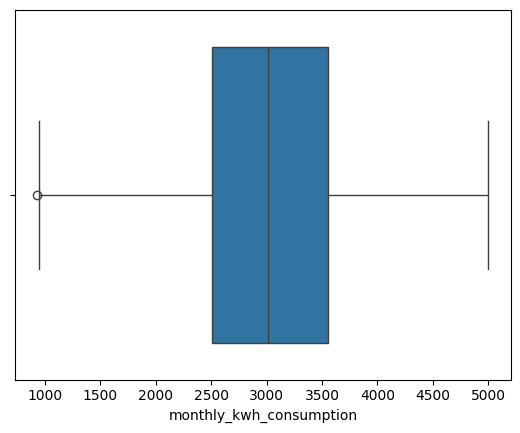

In [200]:
# df_energy['monthly_kwh_consumption'].plot(figsize=(10,5))

sb.boxplot(x=df_energy['monthly_kwh_consumption'])

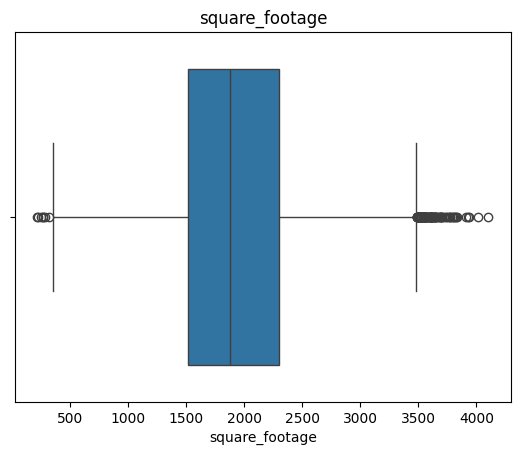

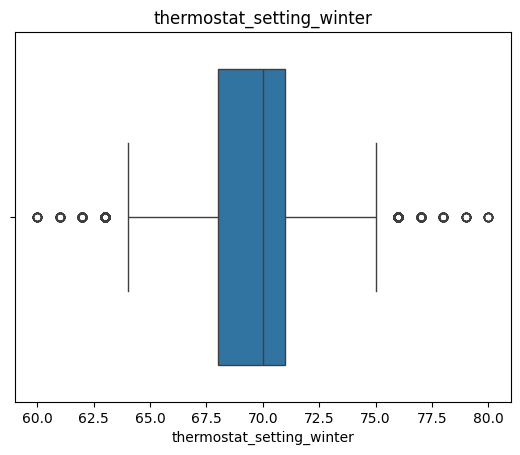

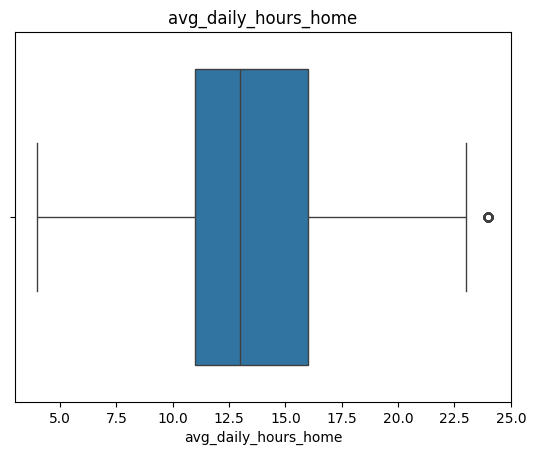

In [201]:
cols = ['square_footage', 'thermostat_setting_winter', 'avg_daily_hours_home']
 
for col in cols:
    plt.figure()
    sns.boxplot(x=df_energy[col])
    plt.title(col)
    plt.show()

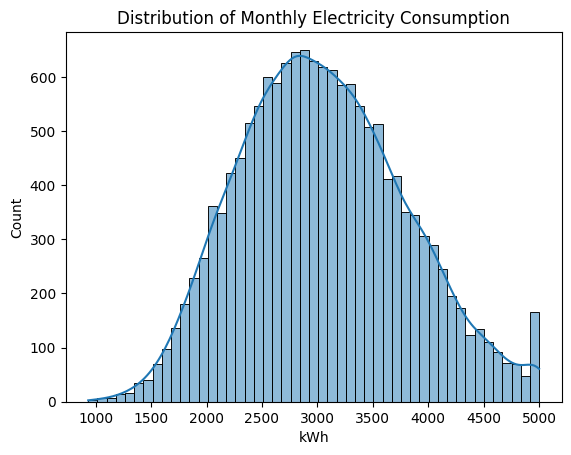

In [202]:


sns.histplot(df_energy['monthly_kwh_consumption'], kde=True)
plt.title("Distribution of Monthly Electricity Consumption")
plt.xlabel("kWh")
plt.show()

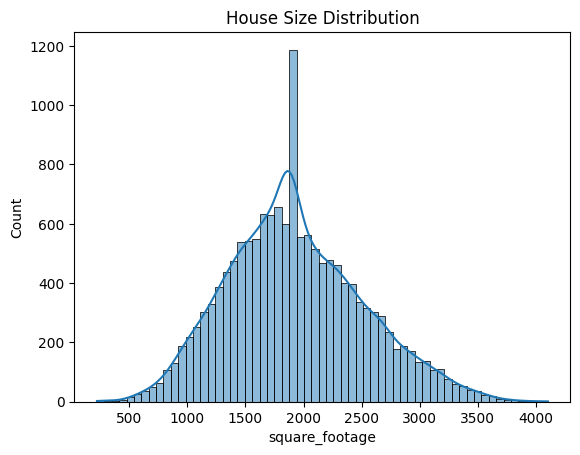

In [203]:
sns.histplot(df_energy['square_footage'], kde=True)
plt.title("House Size Distribution")
plt.show()

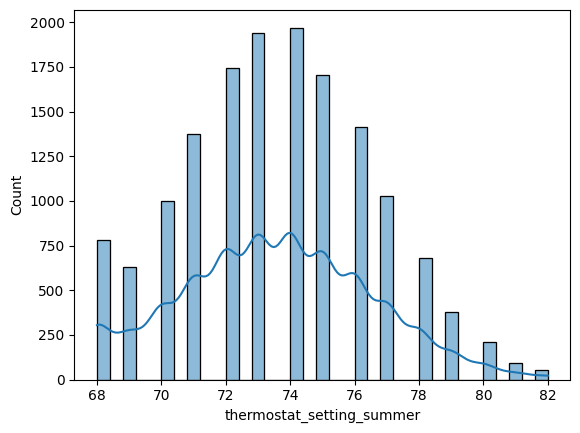

In [204]:
sns.histplot(df_energy['thermostat_setting_summer'], kde=True)
plt.show()

In [205]:
df_energy.columns

Index(['household_size', 'num_adults', 'num_children', 'income_bracket',
       'square_footage', 'num_bedrooms', 'num_bathrooms', 'house_age_years',
       'insulation_quality', 'num_floors', 'thermostat_setting_winter',
       'thermostat_setting_summer', 'num_refrigerators', 'num_tvs',
       'num_computers', 'avg_daily_hours_home', 'electric_vehicle_count',
       'monthly_kwh_consumption', 'area_per_person', 'bath_bed_ratio',
       'temp_diff', 'appliance_count', 'home_ownership_Rent',
       'house_type_Condo', 'house_type_Single Family', 'house_type_Townhouse',
       'has_basement_Yes', 'heating_type_Gas', 'heating_type_Heat Pump',
       'heating_type_Oil', 'heating_type_Other', 'cooling_type_Heat Pump',
       'cooling_type_Window Units', 'climate_zone_Hot', 'climate_zone_Mixed',
       'climate_zone_Moderate', 'has_dishwasher_Yes', 'has_washer_dryer_Yes',
       'has_electric_water_heater_Yes', 'has_pool_Yes', 'has_spa_hot_tub_Yes',
       'has_smart_thermostat_Yes', 'has_l

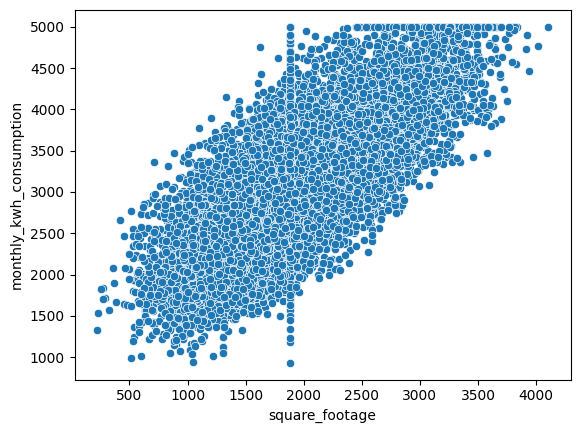

In [206]:
sns.scatterplot(x=df_energy['square_footage'], 
                y=df_energy['monthly_kwh_consumption'])
plt.show()

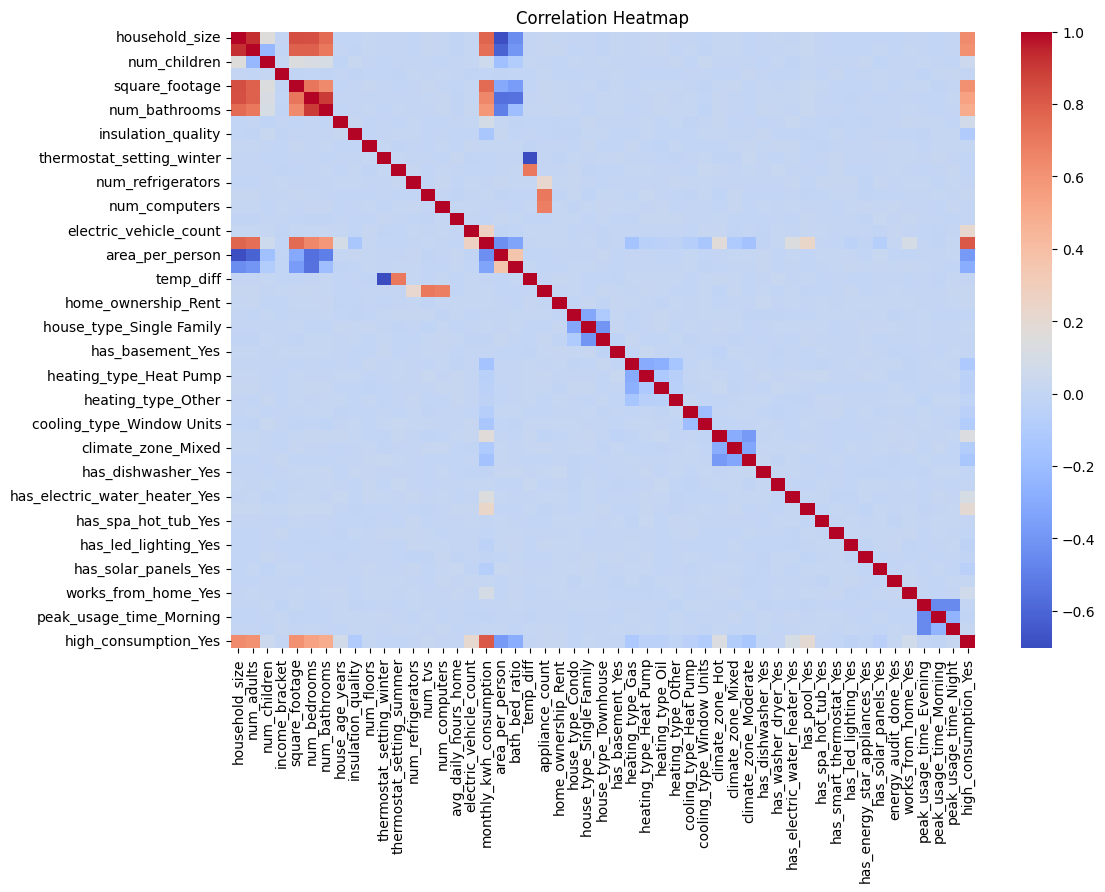

In [207]:
plt.figure(figsize=(12,8))
sns.heatmap(df_energy.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Insulation Quality
## Hypothesis 1: Insulation Quality impacts Electricity Consumption
- H0: Insulation quality has no effect
- H1: Insulation quality significantly affects electricity consumptionfrom scipy.stats import f_oneway

In [208]:
from scipy.stats import pearsonr
 
 
groups = [
    df_energy[df_energy['insulation_quality'] == 0]['monthly_kwh_consumption'],
    df_energy[df_energy['insulation_quality'] == 1]['monthly_kwh_consumption'],
    df_energy[df_energy['insulation_quality'] == 2]['monthly_kwh_consumption'],
    df_energy[df_energy['insulation_quality'] == 3]['monthly_kwh_consumption']
]
 
f_stat, p_value = f_oneway(*groups)
 
print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 120.90365920636847
P-value: 2.256745654080168e-77


Appliances vs Consumption
## Hypothesis 2: Number of Appliances impacts Electricity Consumption
 
- H0: Number of appliances has no effect
- H1: Number of appliances significantly affects electricity consumption

In [212]:
corr, p_value = pearsonr(df_energy['appliance_count'], df_energy['monthly_kwh_consumption'])
 
print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.0063119320982401115
P-value: 0.4395259774362589


Household Size vs Consumption
## Hypothesis 3: Household Size impacts Electricity Consumption
 
- H0 (Null Hypothesis): Household size has no effect on electricity consumption
- H1 (Alternative Hypothesis): Household size significantly affects electricity consumption

In [214]:
corr, p_value = pearsonr(df_energy['household_size'], df_energy['monthly_kwh_consumption'])
 
print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.769704048494126
P-value: 0.0


Work From Home Effect (T-Test)
## Hypothesis 4: Work From Home impacts Electricity Consumption
 
- H0: No difference in consumption between WFH and non-WFH households
- H1: Significant difference exists

In [215]:
wfh = df_energy[df_energy['works_from_home'] == 1]['monthly_kwh_consumption']
non_wfh = df_energy[df_energy['works_from_home'] == 0]['monthly_kwh_consumption']
 
t_stat, p_value = ttest_ind(wfh, non_wfh)
 
print("T-statistic:", t_stat)
print("P-value:", p_value)

KeyError: 'works_from_home'